In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    ('dsa74qvm', 'SM'): {},
    ('z6by8yki', 'SM-TF'): {},
    # ('i9eiw52a', r'SM (VE)'): {},
    # ('9iyfvln5', r'FM (OT)'): {},
    # ('vewqv512', r'FM (VE)'): {},
    # ('bwwbytsc', r'FM-TF (OT,Euler)'): {},
    # ('4wlfk2ww', r'FM-TF (OT)'): {},
    # ('3iz7hm6a', r'FM-TF (OT,$\mathcal{L}_{\mathrm{FM}}$)'): {},
    # ('ny8j7nt4', r'FM-TF ($x_1-x_0$, $\lambda = 1$)'): {},
    # ('3mer31qu', r'FM-TF ($u_t(x|x_1)$, $\lambda=1$)'): {},
    # ('0wrmfaku', r'FM-TF ($u_t(x|x_1)$, $\lambda=1$, Resample $x_0$)'): {},
    # ('5xlltk8g', r'FM-TF ($u_t(x|x_1)$, $\lambda=1.5$)'): {},
    # ('5d2rymkn', r'FM-TF ($u_t(x|x1)$, $\lambda=2$)'): {},
}
label_to_alt_id = dict(map(reversed, alt_ids))
assert len(alt_ids) == len(label_to_alt_id), "Do two alt_id's have the same plot label?"

In [4]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('dsa74qvm', 'SM'): {'cfg': Conf(root_dir='/home/sci/ttransue/GitHub/Data-Assimilation-Flow-Matching',
                                  out_dir='/home/sci/ttransue/out/dafm',
                                  run_subdir='runs',
                                  prediction_filename='trajectories.parquet',
                                  device='cpu',
                                  alt_id='dsa74qvm',
                                  rng_seed=2376999025,
                                  fit=True,
                                  id=28,
                                  dataset=DoubleWell(predicted_state_count=1000,
                                                     time_step_count=100,
                                                     time_step_count_drop_first=0,
                                                     time_step_size=0.1,
                                                     observe_every_n_time_steps=1,
                                                     obse

In [5]:
for v in cfgs.values():
    v['trajectories'] = pd.read_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)

In [6]:
dim = 0
for v in cfgs.values():
    v['trajectories'][f'predicted_state_mean_{dim}'] = v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.contains(f'predicted_state_[0-9]+_dim_{dim}')]].mean(axis=1)

In [7]:
(
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k[1] for k in cfgs], names=['Model'])
    .groupby(level='Model')
    [[f'true_state_dim_{dim}', f'predicted_state_mean_{dim}']]
    .apply(lambda x: (x[f'true_state_dim_{dim}'] - x[f'predicted_state_mean_{dim}']).pow(2).mean()**(1/2))
    .rename('RMSE')
    .to_frame()
)

,RMSE
Model,
SM,0.107061
SM-TF,0.109664


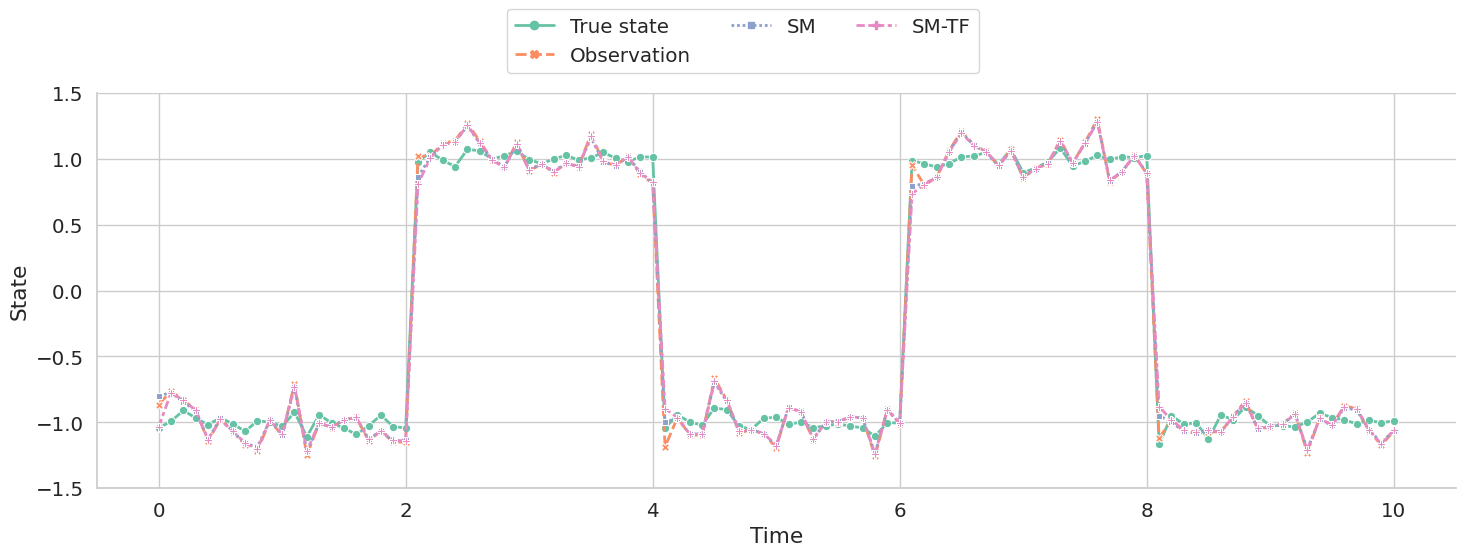

In [8]:
df_line = pd.concat([
    v['trajectories']['times'].rename('Time'),
    v['trajectories'][f'true_state_dim_{dim}'].rename('True state'),
    v['trajectories'][f'observation_dim_{dim}'].rename('Observation'),
    *(
        v['trajectories'][f'predicted_state_mean_{dim}'].rename(f'{k[1]}')
        for k, v in cfgs.items()
    )
], axis=1)
df_line_melt = df_line.melt(id_vars=['Time'], var_name='Source', value_name='State')
plot = (
    sns.relplot(
        data=df_line_melt,
        kind='line',
        x='Time',
        y='State',
        hue='Source',
        style='Source',
        markers=True,
        aspect=3,
        linewidth=2,
        # hue_order=['true_state', 'predicted_state_mean'],
    )
    .set(ylim=(-1.5, 1.5))
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=min(len(df_line_melt['Source'].unique()), 3),
    title='',
    bbox_to_anchor=(.455, 1.14),
    frameon=True,
    fancybox=True,
)

In [9]:
plots.save_all_subfigures(plot, 'Predictions', renaming=label_to_alt_id)

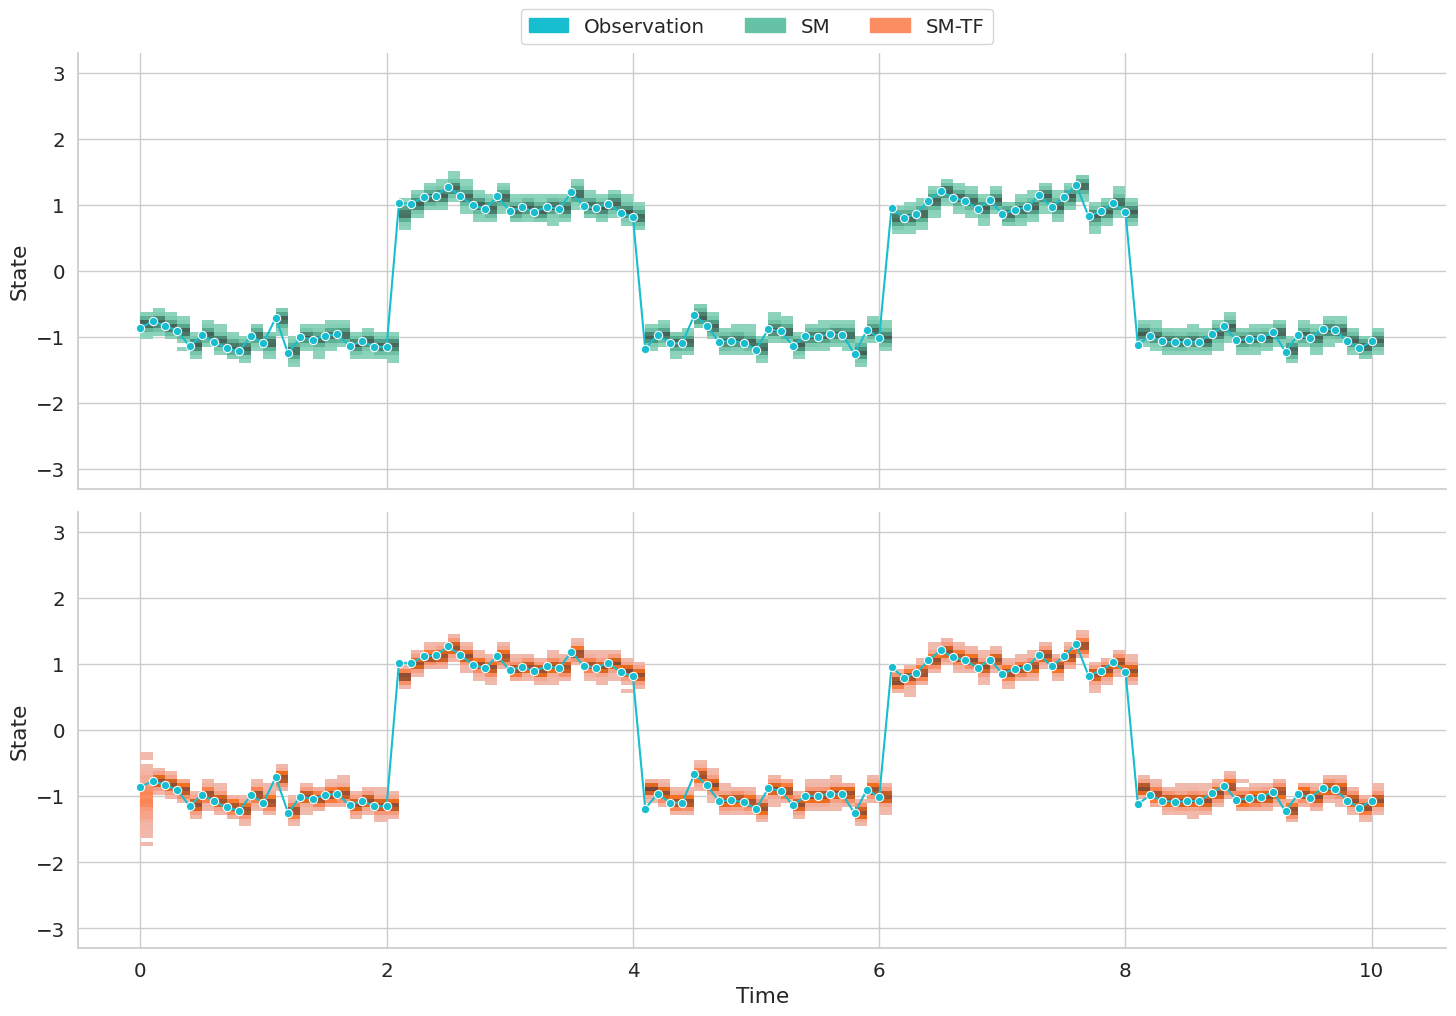

In [10]:
dim = 0
df_hist = (
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k[1] for k in cfgs], names=['Model'])
    .reset_index()
    .melt(id_vars=['Model', 'times'], var_name='Source', value_name='State', value_vars=v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')])
    .rename(columns={'times': 'Time'})
)
#.melt(id_vars=['Time'], var_name='Source', value_name='State')
df_hist
plot = (
    sns.displot(
        data=df_hist,
        x='Time',
        y='State',
        row='Model',
        hue='Model',
        hue_order=['Observation', *df_hist['Model'].unique()],# 'True state'],
        palette=['tab:cyan', *sns.color_palette()[:len(df_hist['Model'].unique())]],# 'tab:red'],
        bins=(v['trajectories']['times'], 101),
        binwidth=(v['trajectories']['times'].diff().iloc[-1], None),
        aspect=3,
        common_norm=False,
        binrange=(None, (-3, 3)),
    )
    .set_titles('')
    # .set(xticks=[])
)
plot.map(
    sns.lineplot,
    data=df_line_melt.loc[(df_line_melt['Source'] == 'Observation'), ['Time', 'State', 'Source']],
    x='Time',
    y='State',
    color='tab:cyan',
    style='Source',
    markers=True,
)
# plot.map(
#     sns.lineplot,
#     data=df_line_melt.loc[(df_line_melt['Source'] == 'True state'), ['Time', 'State', 'Source']],
#     x='Time',
#     y='State',
#     color='tab:red',
#     style='Source',
#     markers=True,
# )
sns.move_legend(
    plot,
    loc='upper center',
    ncol=min(len(df_hist['Source'].unique()), 3),
    title='',
    bbox_to_anchor=(.455, 1.03),
    frameon=True,
    fancybox=True,
)

In [11]:
plots.save_all_subfigures(plot, 'PredictedStateHistogram', renaming=label_to_alt_id)

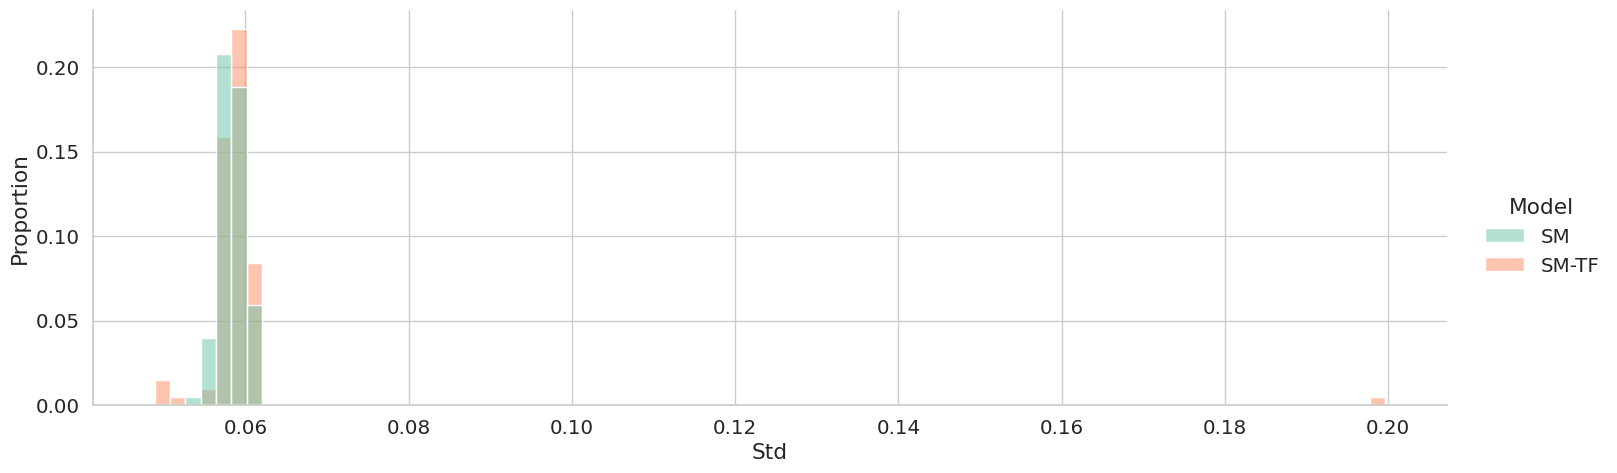

In [12]:
std = pd.concat([
    v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')]]
    .std(axis=1)
    .rename('Std')
    for k, v in cfgs.items()
], keys=[k[1] for k in cfgs], names=['Model']).reset_index()
plot = (
    sns.displot(
        data=std,
        x='Std',
        hue='Model',
        stat='proportion',
        aspect=3,
        bins=80,
    )
)
# plot.axes[0][0].set_xticks(np.arange(0, std['Std'].max() + .1, .1))
plot

In [13]:
std

,Model,level_1,Std
0,SM,0,0.053889
1,SM,1,0.059761
2,SM,2,0.060598
3,SM,3,0.055648
4,SM,4,0.056051
...,...,...,...
197,SM-TF,96,0.057569
198,SM-TF,97,0.059868
199,SM-TF,98,0.057250
200,SM-TF,99,0.055514


In [14]:
stats = pd.concat([
    v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')]]
    .std(axis=1, ddof=0)
    .describe()
    .rename(k[1])
    .to_frame().T
    for k, v in cfgs.items()
])
print(stats[stats.columns[stats.columns != 'count']].to_latex())

\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & 25% & 50% & 75% & max \\
\midrule
SM & 0.058250 & 0.001514 & 0.053862 & 0.057209 & 0.058224 & 0.059272 & 0.061537 \\
SM-TF & 0.059879 & 0.014205 & 0.048832 & 0.057722 & 0.058801 & 0.059856 & 0.199555 \\
\bottomrule
\end{tabular}

